# Análisis EDA y Clasificación de Tickets de Incidentes Bancarios

Este notebook realiza un análisis exploratorio de datos (EDA) y un modelo de clasificación para predecir la categoría de cada ticket de incidentes bancarios a partir de un archivo CSV.

## 1. Carga de Librerías y Configuración Inicial

In [347]:
# ── Librería estándar ─────────────────────────────────────────────────────────
import os
import re
import unicodedata
import warnings
from collections import Counter

# ── Datos y visualización ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── Procesamiento de texto ────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords

# ── Estadística y matrices dispersas ─────────────────────────────────────────
from scipy.stats import f_oneway
from scipy.sparse import vstack

# ── Scikit-learn: features y preprocesamiento ────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Scikit-learn: modelos ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: selección de modelos y métricas ────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

# ── Imbalanced-learn ─────────────────────────────────────────────────────────
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings('ignore')

# ── Configuración de gráficos ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (10, 6)})


## 2. Carga y Exploración Inicial de Datos

In [348]:
# Cargar el archivo CSV
# Ruta relativa desde Analisis/ hacia Data/ (un nivel arriba)
ruta_csv = os.path.join(os.path.dirname(os.getcwd()), 'Data', 'IncidentesCategorizados-Final.csv')
print('Directorio actual:', os.getcwd())
print('Ruta CSV:', ruta_csv)

# Intenta cargar el archivo
try:
    df = pd.read_csv(ruta_csv, sep=',', encoding='latin-1')
except FileNotFoundError as e:
    print('No se encontró el archivo. Verifica la ruta y ubicación.')
    raise e

# Mostrar primeras filas y resumen
print('Dimensiones:', df.shape)
df.head()


Directorio actual: c:\Users\paomaribel\Documents\GitHub\Asignador\Analisis
Ruta CSV: c:\Users\paomaribel\Documents\GitHub\Asignador\Data\IncidentesCategorizados-Final.csv
Dimensiones: (7353, 30)


,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,cmdb_ci,...,location.cmn_location_type,assignment_group,assigned_to,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error,Categoría
0,INC0755414,Nuevo,19/02/2026 16:30:59,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,NANCY CECILIA NASIMBA CHALCO,segun ticket ingresado RITM0800991 me sugiere...,NaN,NaN,NaN,NaN,NaN,Activos
1,INC0754016,Nuevo,18/02/2026 23:00:43,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0.0,Bancs,NaN,...,Edificio/Estructura,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,CON FECHA 22 DE ENERO 2026 LAS OPERACIONES 800...,NaN,NaN,NaN,NaN,NaN,Activos
2,INC0754538,Nuevo,19/02/2026 09:55:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,"Favor su apoyo, revisando el abono al capital,...",NaN,NaN,NaN,NaN,NaN,Activos
3,INC0753295,Nuevo,18/02/2026 14:30:54,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,por favor su ayuda con la regularización para ...,18/02/2026 17:35:05 - JOAO CRISTOFFER PEREZ PA...,NaN,NaN,NaN,NaN,Activos
4,INC0756601,Nuevo,20/02/2026 10:46:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LEONELA JACKELINE DELGADO MENDIETA,su gentil ayuda con el siguiente caso la clien...,NaN,NaN,NaN,NaN,NaN,NaN


In [349]:
# Tipos de datos y valores nulos
df.info()
df.isnull().sum().sort_values(ascending=False).head(15)

<class 'pandas.DataFrame'>
RangeIndex: 7353 entries, 0 to 7352
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   number                      7353 non-null   str    
 1   state                       7352 non-null   str    
 2   sys_created_on              7352 non-null   str    
 3   category                    7352 non-null   str    
 4   u_subcategory               7352 non-null   str    
 5   u_subcategory_2             7352 non-null   str    
 6   contact_type                7352 non-null   str    
 7   business_duration           7352 non-null   float64
 8   cmdb_ci_business_app        4792 non-null   str    
 9   cmdb_ci                     2329 non-null   str    
 10  short_description           7352 non-null   str    
 11  priority                    7352 non-null   str    
 12  severity                    7352 non-null   str    
 13  caller_id                   7352 non-null   

cmdb_ci                       5024
cmdb_ci_business_app          2561
comments_and_work_notes       1454
u_subcategoria_error           642
u_categoria_error              640
location.cmn_location_type     588
location                       588
Categoría                      316
u_affected_user.department     117
resolved_at                     28
close_notes                     27
assigned_to                      8
description                      6
u_affected_user                  4
u_affected_user.title            4
dtype: int64

In [350]:
# Exploración rápida de variables informativas
print('\nPorcentaje de valores nulos por columna:')
print((df.isnull().mean()*100).sort_values(ascending=False))
print('\nNúmero de valores únicos por columna:')
print(df.nunique().sort_values(ascending=False))

# Sugerencia de variables informativas (no ID, no columnas vacías o con un solo valor)
columnas_informativas = [col for col in df.columns if df[col].nunique()>1 and df[col].nunique()<df.shape[0]*0.9 and not col.lower().startswith('id')]
print('\nColumnas potencialmente informativas:')
print(columnas_informativas)



Porcentaje de valores nulos por columna:
cmdb_ci                       68.325853
cmdb_ci_business_app          34.829321
comments_and_work_notes       19.774242
u_subcategoria_error           8.731130
u_categoria_error              8.703930
location.cmn_location_type     7.996736
location                       7.996736
Categoría                      4.297566
u_affected_user.department     1.591187
resolved_at                    0.380797
close_notes                    0.367197
assigned_to                    0.108799
description                    0.081599
u_affected_user                0.054400
u_affected_user.title          0.054400
u_affected_user.company        0.054400
priority                       0.013600
severity                       0.013600
sys_created_on                 0.013600
caller_id                      0.013600
u_subcategory_2                0.013600
short_description              0.013600
contact_type                   0.013600
state                          0.01360

## 3. Limpieza y Preprocesamiento de Datos

## 3.1 Columna Clasificación

In [351]:
# Cambiar el nombre de la columna 'Categoria' por 'Clasificación'
df = df.rename(columns={"Categoría": "Clasificación"})

In [352]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(conteo_clases)

Clasificación
0                         3393
BancsLink                  711
Activos                    543
Cuentas                    437
Inversiones                369
Pendiente                  329
NaN                        316
Contabilidad               221
Formas numeradas           169
Chequeras                  151
Cheques                    150
SISREP                     132
Reportes Batch              77
Garantías                   51
Estados de Cuenta           47
No productivo               43
Clientes                    41
Retenciones Judiciales      39
Firmas autorizadas          29
Incidencias                 17
Estados de cuenta           15
Cartola                     15
No aplica                   14
Sobregiros                  11
Formas Numeradas            11
Firmas Autorizadas           9
CNBs                         5
MT940                        3
Cuentas                      2
CC-Cancelación batch         2
CC-Evento/alerta             1
Name: count, dtype: int64

In [353]:
# Revisar valores únicos y nulos en 'Clasificación'
if 'Clasificación' in df.columns:
    print('Valores únicos en Clasificación:', df['Clasificación'].unique())
    print('Valores nulos en Clasificación:', df['Clasificación'].isnull().sum())
else:
    print("La columna 'Clasificación' no está presente en el DataFrame.")

Valores únicos en Clasificación: <StringArray>
[               'Activos',                      nan,      'Estados de cuenta',
             'Sobregiros',         'Reportes Batch',       'Formas numeradas',
                      '0',              'Chequeras',                'Cheques',
                 'SISREP',              'BancsLink',            'Inversiones',
           'Contabilidad',              'Pendiente',                'Cuentas',
              'No aplica',          'No productivo',              'Garantías',
            'Incidencias',               'Clientes',      'Estados de Cuenta',
       'Formas Numeradas',     'Firmas Autorizadas', 'Retenciones Judiciales',
               'Cuentas ',     'Firmas autorizadas',                'Cartola',
                   'CNBs',   'CC-Cancelación batch',                  'MT940',
       'CC-Evento/alerta']
Length: 31, dtype: str
Valores nulos en Clasificación: 316


In [354]:
# Normalización de valores en la columna 'Clasificación'
def normalizar_texto(texto):
    if pd.isnull(texto):
        return "sin_clasificar"
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'\s+', ' ', texto)
    texto = texto.replace('.', '')
    texto = texto.replace('/', '-')
    texto = texto.strip()
    return texto

df['Clasificación'] = df['Clasificación'].apply(normalizar_texto)

# Verifica los valores únicos después de la normalización
print(df['Clasificación'].unique())


<StringArray>
[               'activos',         'sin_clasificar',      'estados de cuenta',
             'sobregiros',         'reportes batch',       'formas numeradas',
                      '0',              'chequeras',                'cheques',
                 'sisrep',              'bancslink',            'inversiones',
           'contabilidad',              'pendiente',                'cuentas',
              'no aplica',          'no productivo',              'garantias',
            'incidencias',               'clientes',     'firmas autorizadas',
 'retenciones judiciales',                'cartola',                   'cnbs',
   'cc-cancelacion batch',                  'mt940',       'cc-evento-alerta']
Length: 27, dtype: str


In [355]:
# 1. Agrupar valores en plural y singular en la columna 'Clasificación'
agrupaciones_plural = {
    'cheques': 'cheque',
    'cuentas': 'cuenta',
    'activos': 'activo',
    'garantias': 'garantia',
    'inversiones': 'inversion',
    'sobregiros': 'sobregiro',
    'usuarios': 'usuario',
    'procesos': 'proceso',
    'clientes': 'cliente',
    'reportes online': 'reporte online',
    'reportes batch': 'reporte batch',
    'formas numeradas': 'forma numerada',
    # Agregar más se detectan otros casos
}
df['Clasificación'] = df['Clasificación'].replace(agrupaciones_plural)

In [356]:
# Reemplazar valores sin clasificar y pendientes → sin_clasificar
df['Clasificación'] = df['Clasificación'].replace(
    ['0', 0, None, np.nan, 'no aplica', 'pendiente'],
    'sin_clasificar'
)

# Eliminar filas con clases que tienen muy pocos ejemplos para entrenar (< 3)
clases_a_eliminar = ['cc-cancelacion batch', 'cc-evento-alerta']
filas_antes = len(df)
df = df[~df['Clasificación'].isin(clases_a_eliminar)].reset_index(drop=True)
print(f"Filas eliminadas: {filas_antes - len(df)}  ({clases_a_eliminar})")
print(f"Total filas restantes: {len(df)}")


Filas eliminadas: 3  (['cc-cancelacion batch', 'cc-evento-alerta'])
Total filas restantes: 7350


In [357]:
# 3. Asignar 'mt940' a 'forma numerada'
df['Clasificación'] = df['Clasificación'].replace('mt940', 'forma numerada')

In [358]:
# Verifica los valores únicos después de la normalización
print(df['Clasificación'].unique())


<StringArray>
[                'activo',         'sin_clasificar',      'estados de cuenta',
              'sobregiro',          'reporte batch',         'forma numerada',
              'chequeras',                 'cheque',                 'sisrep',
              'bancslink',              'inversion',           'contabilidad',
                 'cuenta',          'no productivo',               'garantia',
            'incidencias',                'cliente',     'firmas autorizadas',
 'retenciones judiciales',                'cartola',                   'cnbs']
Length: 21, dtype: str


In [359]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(f"Total de clases de Clasificación: {conteo_clases.shape[0]}")
print()
print(conteo_clases)


Total de clases de Clasificación: 21

Clasificación
sin_clasificar            4052
bancslink                  711
activo                     543
cuenta                     439
inversion                  369
contabilidad               221
forma numerada             183
chequeras                  151
cheque                     150
sisrep                     132
reporte batch               77
estados de cuenta           62
garantia                    51
no productivo               43
cliente                     41
retenciones judiciales      39
firmas autorizadas          38
incidencias                 17
cartola                     15
sobregiro                   11
cnbs                         5
Name: count, dtype: int64


In [360]:
# Verificar duplicados en el DataFrame
duplicados = df[df.duplicated()]
print(f"Número de filas duplicadas: {duplicados.shape[0]}")
if not duplicados.empty:
    display(duplicados.head())
else:
    print("No se encontraron filas duplicadas.")

Número de filas duplicadas: 0
No se encontraron filas duplicadas.


## 4. Análisis Exploratorio de Datos (EDA)


--- severity ---


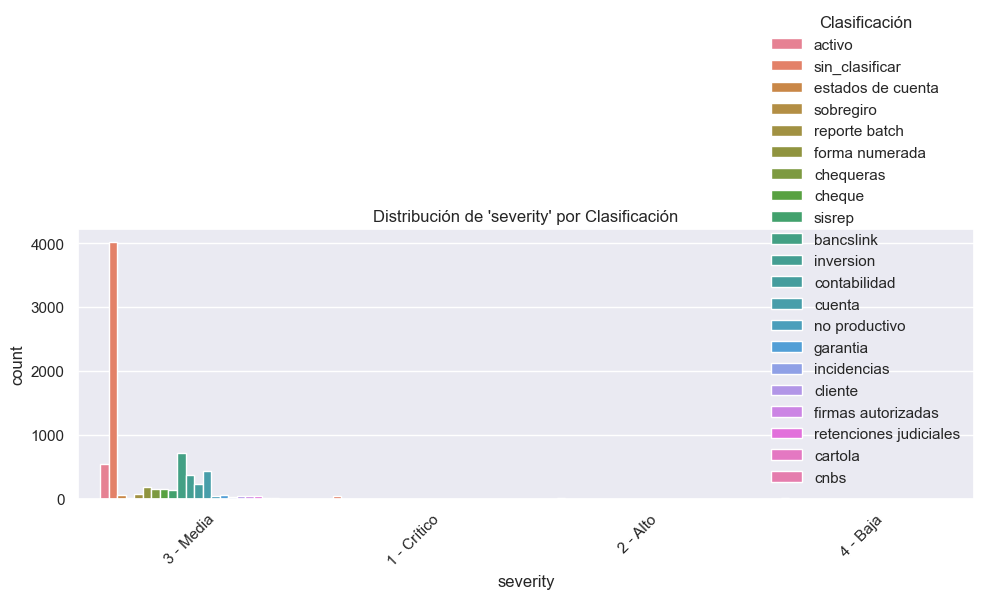

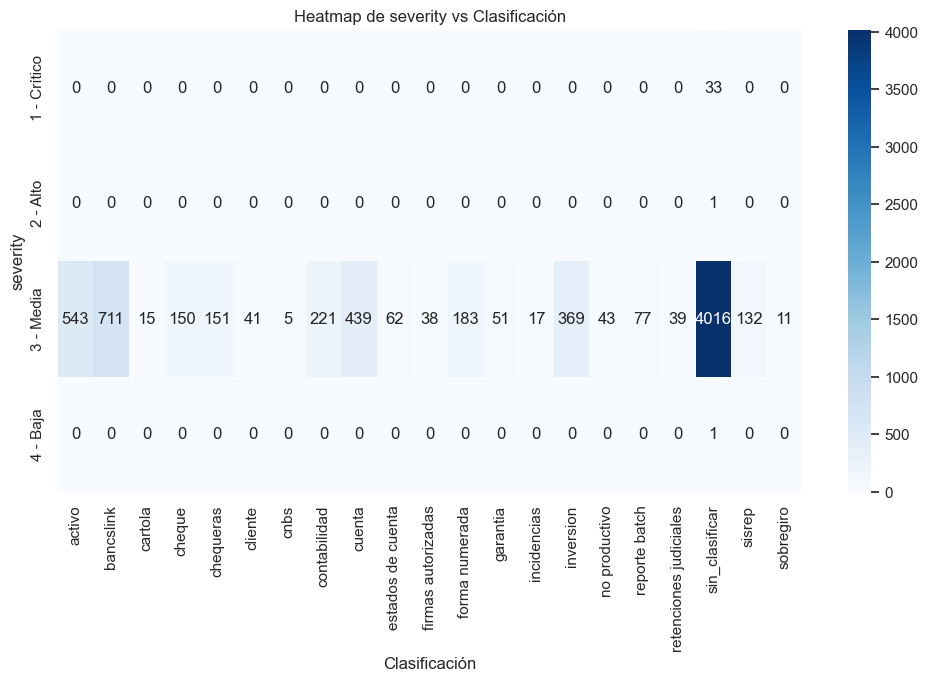


--- contact_type ---


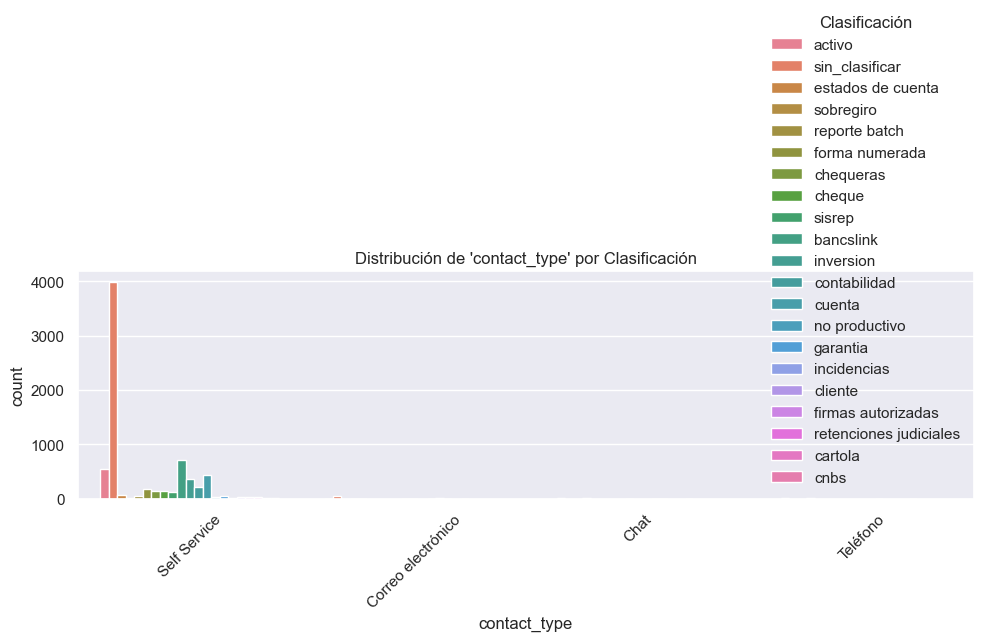

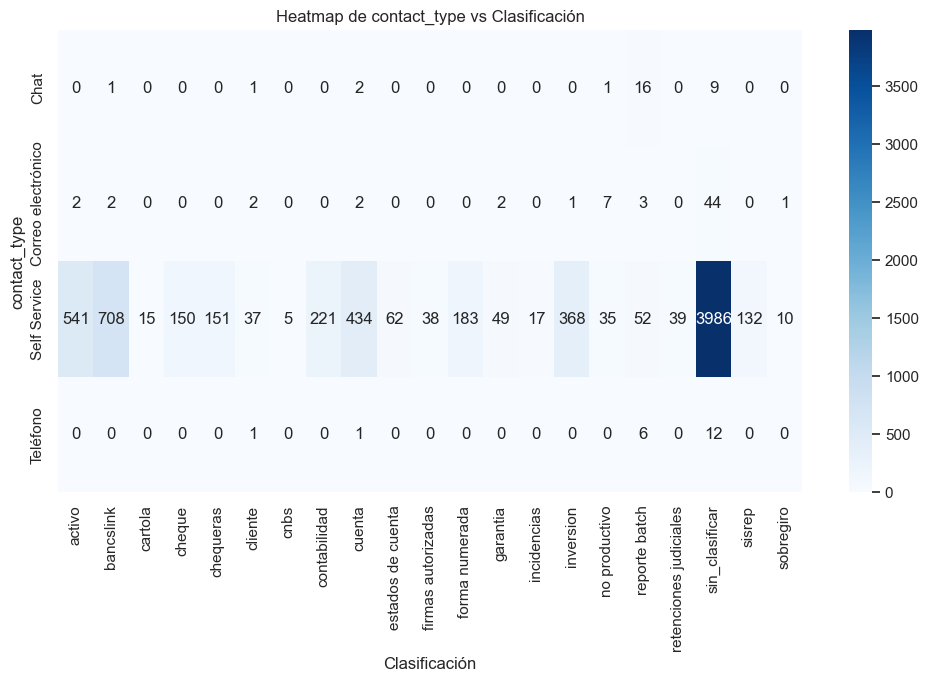


--- assignment_group ---


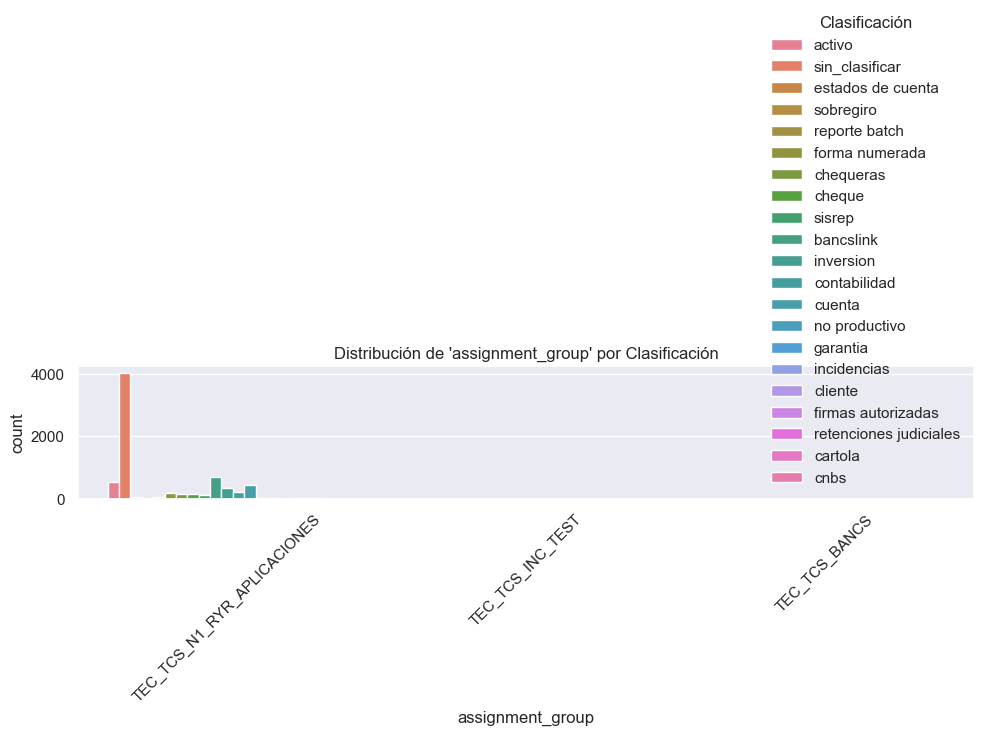

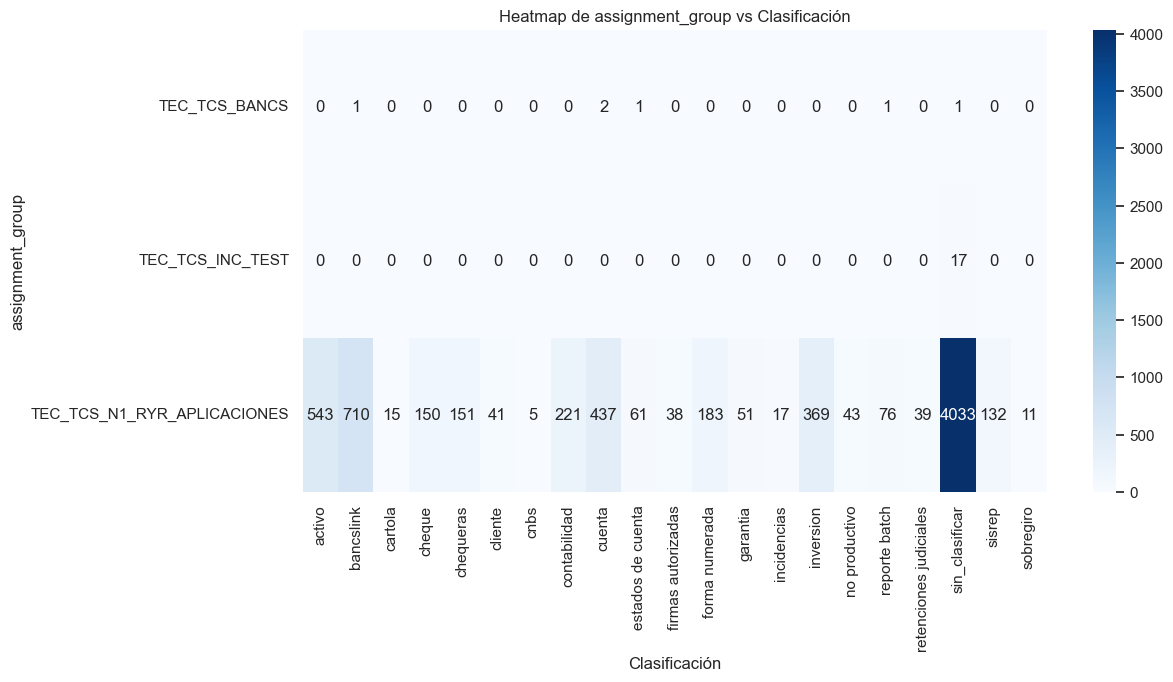


--- u_subcategory ---


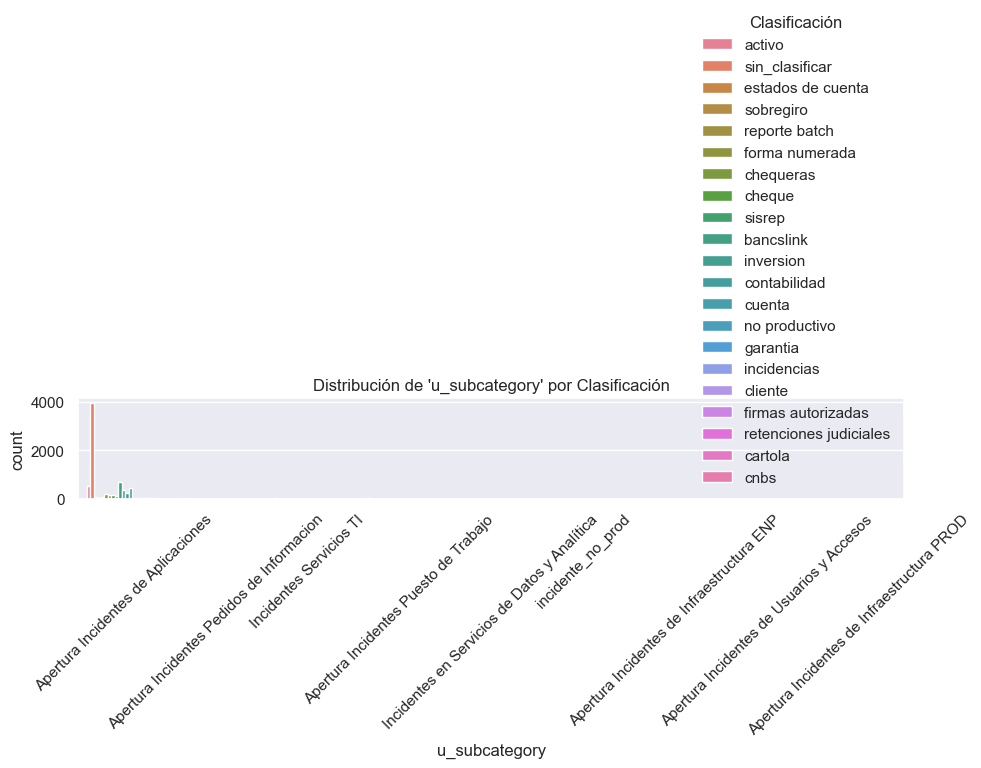

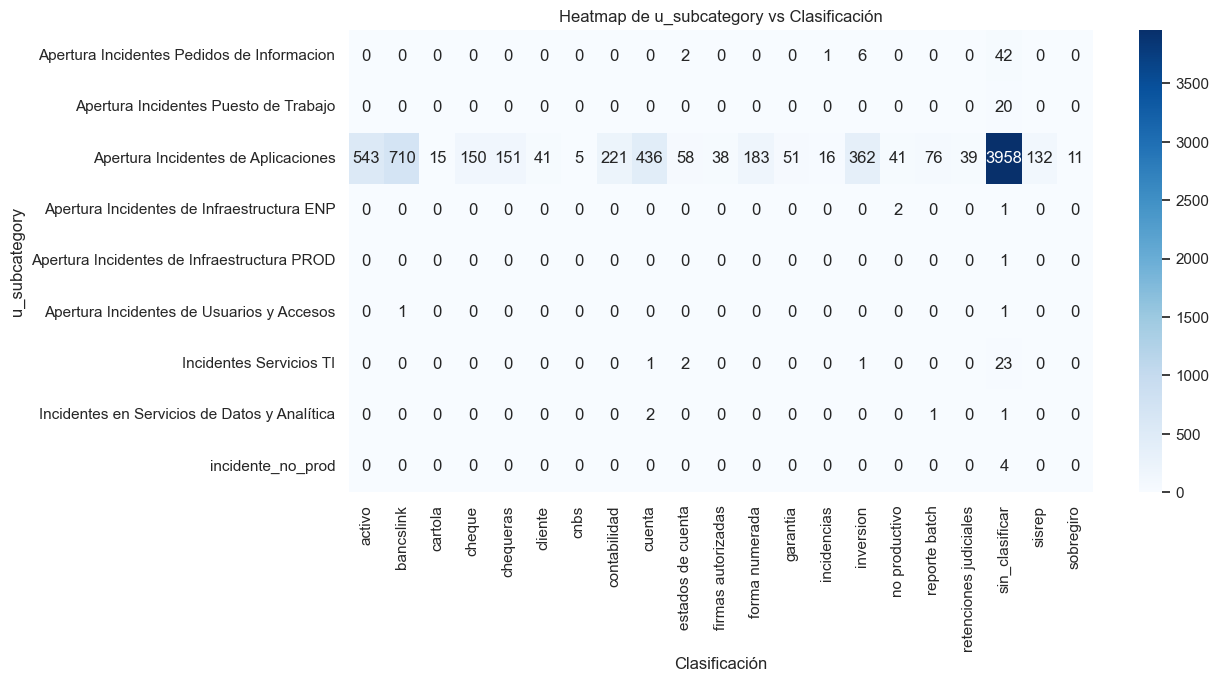


--- u_subcategory_2 ---


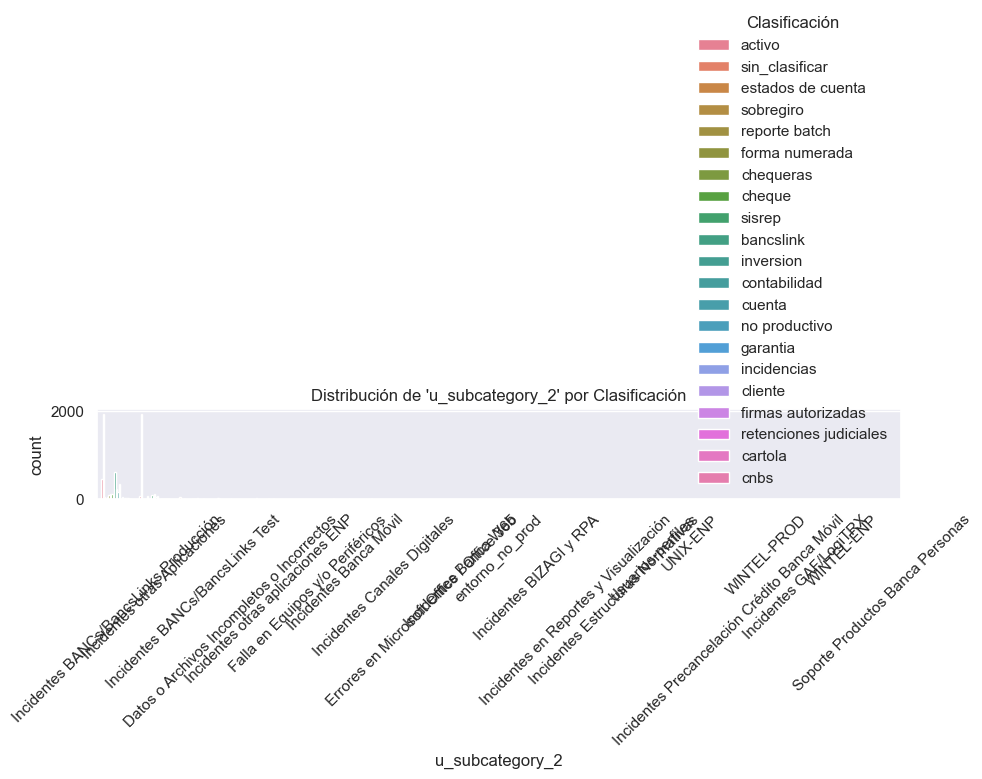

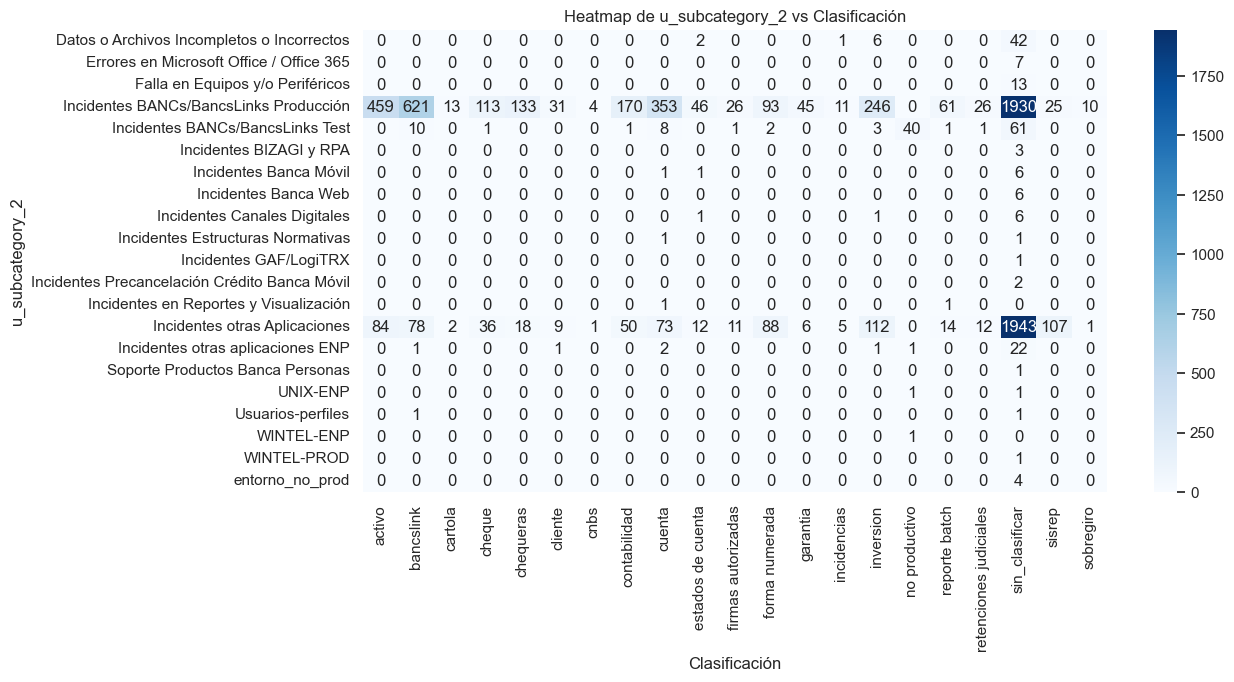

In [361]:
# Gráficos de barras apiladas y heatmaps para columnas categóricas relevantes
columnas_categoricas = [
    'priority', 'severity', 'contact_type', 'assignment_group', 'Origen', 'Ambiente',
    'u_subcategory', 'u_subcategory_2'
]

for col in columnas_categoricas:
    if col in df.columns and df[col].nunique() > 1 and df[col].nunique() < 25:
        print(f"\n--- {col} ---")
        # Gráfico de barras apiladas
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=col, hue='Clasificación', order=df[col].value_counts().index)
        plt.title(f"Distribución de '{col}' por Clasificación")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        # Heatmap de la tabla de contingencia
        tabla = pd.crosstab(df[col], df['Clasificación'])
        plt.figure(figsize=(12, 6))
        sns.heatmap(tabla, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Heatmap de {col} vs Clasificación")
        plt.show()



Boxplot y ANOVA: business_duration vs Clasificación


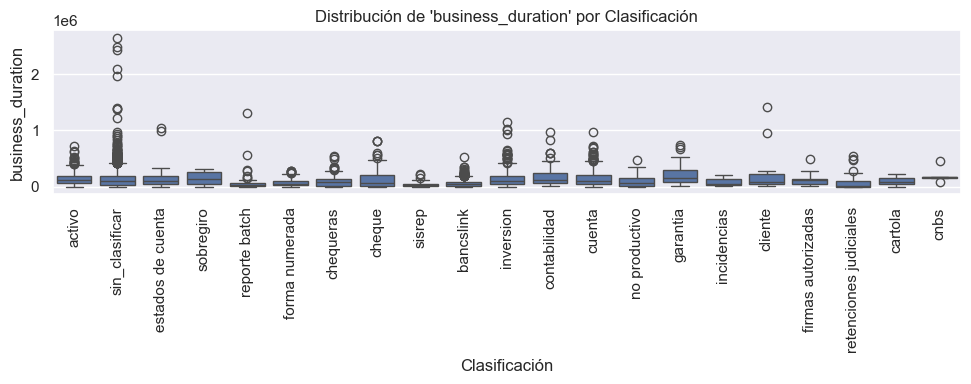

p-valor ANOVA: nan

Boxplot y ANOVA: reopen_count vs Clasificación


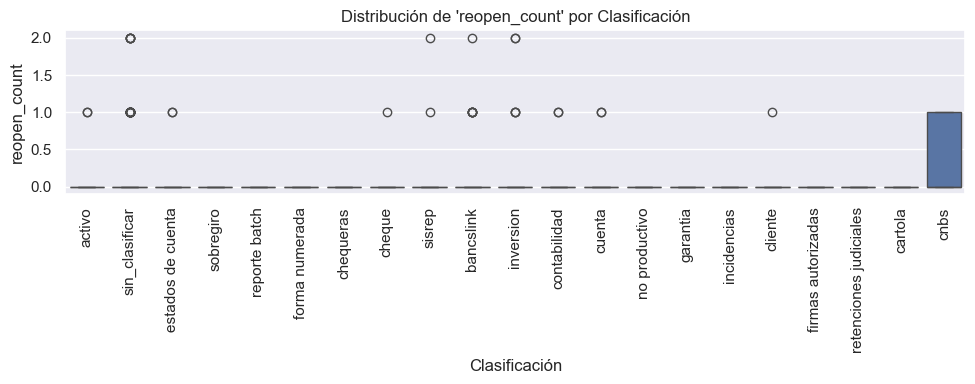

p-valor ANOVA: nan


In [362]:
# 2. Variables numéricas vs. Clasificación (ANOVA y boxplots)
# Recomputar columnas_informativas sobre el df ya renombrado (sin 'Categoría')
columnas_informativas = [
    col for col in df.columns
    if df[col].nunique() > 1
    and df[col].nunique() < df.shape[0] * 0.9
    and not col.lower().startswith('id')
]

num_vars = [col for col in columnas_informativas if df[col].dtype in ['int64', 'float64']]
for col in num_vars:
    print(f"\nBoxplot y ANOVA: {col} vs Clasificación")
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='Clasificación', y=col)
    plt.title(f"Distribución de '{col}' por Clasificación")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    # ANOVA solo si hay más de un grupo
    grupos = [g[1] for g in df.groupby('Clasificación')[col] if len(g[1]) > 1]
    if len(grupos) > 1:
        stat, p = f_oneway(*grupos)
        print(f"p-valor ANOVA: {p:.4f}")


## 5. Preparación de Datos para Modelado

In [363]:
# Cargar stopwords ANTES de limpiar_texto para poder usarlas en la limpieza
nltk.download('stopwords', quiet=True)
spanish_stopwords = set(stopwords.words('spanish'))
print(f"✓ Stopwords cargadas: {len(spanish_stopwords)} palabras")


✓ Stopwords cargadas: 313 palabras


In [364]:
# Unificar texto relevante para análisis de similitud
df['texto_unificado'] = (
    df['short_description'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['u_subcategory'].fillna('') + ' ' +
    df['u_subcategory_2'].fillna('')
)
# Guardar copia del texto crudo ANTES de limpiar (para análisis de duplicados)
df['texto_unificado_raw'] = df['texto_unificado']


In [365]:
# ── Análisis de duplicados exactos en texto_unificado (PRE-limpieza) ──────────
# Usa texto_unificado_raw para que sea robusto sin importar el orden de ejecución.

dup_mask_raw = df['texto_unificado_raw'].duplicated(keep=False)
df_dups_raw = df[dup_mask_raw].copy()

print(f"Tickets con texto_unificado duplicado (crudo): {dup_mask_raw.sum()}  "
      f"({dup_mask_raw.mean():.1%} del total)")
print(f"Textos únicos que se repiten: {df_dups_raw['texto_unificado_raw'].nunique()}")

# Tabla de frecuencias: cuántas veces se repite cada texto y sus clasificaciones
resumen_dups = (
    df_dups_raw
    .groupby('texto_unificado_raw', as_index=False)
    .agg(
        n_tickets       = ('number', 'count'),
        clasificaciones = ('Clasificación', lambda x: ', '.join(sorted(x.unique()))),
        n_clases        = ('Clasificación', 'nunique'),
        ejemplos        = ('number', lambda x: ', '.join(x.head(4).astype(str)))
    )
    .rename(columns={'texto_unificado_raw': 'texto_unificado'})
    .sort_values('n_tickets', ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 textos más repetidos:")
with pd.option_context('display.max_colwidth', 80):
    display(resumen_dups.head(20))

# Duplicados con clasificaciones distintas (ambigüedad real)
ambiguos = resumen_dups[resumen_dups['n_clases'] > 1]
print(f"\nTextos duplicados con DISTINTAS clasificaciones (ambigüedad): {len(ambiguos)}")
if len(ambiguos):
    with pd.option_context('display.max_colwidth', 80):
        display(ambiguos.head(20))


Tickets con texto_unificado duplicado (crudo): 159  (2.2% del total)
Textos únicos que se repiten: 58

Top 20 textos más repetidos:


,texto_unificado,n_tickets,clasificaciones,n_clases,ejemplos
0,ERROR EN SALDOS MONETARIOS AHORROS ESTIMADOS FAVOR SU AYUDA CON LA CORREC ER...,8,contabilidad,1,"INC0427508, INC0434815, INC0427056, INC0427458"
1,Estimados; Por favor su apoyo con la revisión de las operaciones que se regi...,7,sin_clasificar,1,"INC0148831, INC0149865, INC0156630, INC0141189"
2,ESTIMADOS FAVOR SU AYUDA CON LA CORREC ERROR EN SALDOS DE LAS CTA DETALLADAS...,6,sin_clasificar,1,"INC0139358, INC0068696, INC0037870, INC0053554"
3,"ERROR PROHIBICION CHEQUES BANCSLINK Estimados su ayuda, aplicativo Bancslink...",5,"bancslink, cheque",2,"INC0428072, INC0336487, INC0427204, INC0331364"
4,RE-PAGO INVALIDO Estimados por favor su ayuda con la regularización de la op...,5,sin_clasificar,1,"INC0222064, INC0193333, INC0266327, INC0222084"
5,ERROR AL VALIDAR RETENCIONES JUDICIALES Estimados favor su ayuda error al va...,5,retenciones judiciales,1,"INC0318409, INC0327352, INC0313754, INC0319150"
6,ERROR AL VALIDAR RETENCIONES JUDICIALES Estimados favor su ayuda error al va...,4,retenciones judiciales,1,"INC0337893, INC0329607, INC0320612, INC0336481"
7,CORRECCION DE SALDOS MONETARIOS AH ESTIMADOS FAVOR SU AYUDA CON LA CORREC ER...,4,"contabilidad, sin_clasificar",2,"INC0208764, INC0344178, INC0365782, INC0271135"
8,REPAGO INVALIDO REPAGO INVALIDO Apertura Incidentes de Aplicaciones Incident...,4,"activo, sin_clasificar",2,"INC0637434, INC0664028, INC0363736, INC0190105"
9,PENDIENTE FACTURACIÓN GTOS. BANCARIOS Estimados el 03/02/2025 el cliente sol...,4,estados de cuenta,1,"INC0330873, INC0330877, INC0330875, INC0330869"



Textos duplicados con DISTINTAS clasificaciones (ambigüedad): 16


,texto_unificado,n_tickets,clasificaciones,n_clases,ejemplos
3,"ERROR PROHIBICION CHEQUES BANCSLINK Estimados su ayuda, aplicativo Bancslink...",5,"bancslink, cheque",2,"INC0428072, INC0336487, INC0427204, INC0331364"
7,CORRECCION DE SALDOS MONETARIOS AH ESTIMADOS FAVOR SU AYUDA CON LA CORREC ER...,4,"contabilidad, sin_clasificar",2,"INC0208764, INC0344178, INC0365782, INC0271135"
8,REPAGO INVALIDO REPAGO INVALIDO Apertura Incidentes de Aplicaciones Incident...,4,"activo, sin_clasificar",2,"INC0637434, INC0664028, INC0363736, INC0190105"
10,ESTIMADOS FAVOR SU AYUDA CON LA CORREC ERROR EN SALDOS DE LAS CTA DETALLADAS...,3,"contabilidad, sin_clasificar",2,"INC0684927, INC0706296, INC0510595"
12,CORRECCION DE SALDOS MONETARIOS CTES ESTIMADOS FAVOR SU AYUDA CON LA CORREC ...,3,"contabilidad, sin_clasificar",2,"INC0335396, INC0291309, INC0208795"
13,"ERROR PROHIBICION CHEQUES BANCSLINK Estimados su ayuda, aplicativo Bancslink...",3,"bancslink, cheque",2,"INC0423509, INC0316951, INC0313745"
18,2301: CODIGO DE PRIORIDAD DE DESEMBOLSO DEL REPAGO INVALIDO \t\t\t\t\t\t\t\t...,3,"activo, sin_clasificar",2,"INC0268003, INC0269833, INC0423066"
22,2301: CÓDIGO DE PRIORIDAD DE DESEMBOLSO DEL REPAGO INVÁLIDO 2301: CÓDIGO DE ...,2,"activo, sin_clasificar",2,"INC0273822, INC0324752"
27,ERROR EN SALDO MONETARIOS AHORROS ESTIMADOS FAVOR SU AYUDA CON LA CORREC ERR...,2,"contabilidad, sin_clasificar",2,"INC0251813, INC0329055"
30,CORRECCION DE SALDOS MONETARIOS AHORROS ESTIMADOS FAVOR SU AYUDA CON LA CORR...,2,"contabilidad, sin_clasificar",2,"INC0242273, INC0287484"


In [369]:
# ── Tickets del primer grupo de duplicados exactos ────────────────────────────
texto_grupo1 = resumen_dups.iloc[0]['texto_unificado']
n_tickets_g1 = resumen_dups.iloc[0]['n_tickets']
clases_g1    = resumen_dups.iloc[0]['clasificaciones']

print(f"Grupo 1 — {n_tickets_g1} tickets duplicados exactos")
print(f"Clasificaciones: {clases_g1}")
print(f"Texto: {texto_grupo1[:200]}\n")

cols_ver = [c for c in ['number', 'short_description', 'u_subcategory', 'u_subcategory_2', 'Clasificación']
            if c in df.columns]

df_grupo1 = df[df['texto_unificado_raw'] == texto_grupo1][cols_ver].reset_index(drop=True)
display(df_grupo1)


Grupo 1 — 8 tickets duplicados exactos
Clasificaciones: contabilidad
Texto: ERROR EN SALDOS MONETARIOS AHORROS ESTIMADOS FAVOR SU AYUDA CON LA CORREC ERROR EN SALDOS DE LAS CTA DETALLADAS EN EL ADJUNTO. SOLO APLICAR A CTAS ACTIVAS, valores positivos deben ser recuperados (deb



,number,short_description,u_subcategory,u_subcategory_2,Clasificación
0,INC0427508,ERROR EN SALDOS MONETARIOS AHORROS,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,contabilidad
1,INC0434815,ERROR EN SALDOS MONETARIOS AHORROS,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,contabilidad
2,INC0427056,ERROR EN SALDOS MONETARIOS AHORROS,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,contabilidad
3,INC0427458,ERROR EN SALDOS MONETARIOS AHORROS,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,contabilidad
4,INC0434817,ERROR EN SALDOS MONETARIOS AHORROS,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,contabilidad
5,INC0434819,ERROR EN SALDOS MONETARIOS AHORROS,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,contabilidad
6,INC0434808,ERROR EN SALDOS MONETARIOS AHORROS,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,contabilidad
7,INC0426566,ERROR EN SALDOS MONETARIOS AHORROS,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,contabilidad


In [ ]:
# ── Todos los tickets ambiguos (ninguna clasificación es "sin_clasificar") ────
# Textos que tienen 2+ clasificaciones reales distintas
textos_ambiguos_reales = resumen_dups[
    (resumen_dups['n_clases'] > 1) &
    (~resumen_dups['clasificaciones'].str.contains(r'\bsin_clasificar\b', na=False))
]['texto_unificado'].tolist()

cols_ver = [c for c in ['number', 'short_description', 'description',
                         'u_subcategory', 'u_subcategory_2', 'Clasificación']
            if c in df.columns]

# DataFrame con todos los tickets de esos grupos, agrupados por texto
df_tickets_ambiguos = (
    df[df['texto_unificado_raw'].isin(textos_ambiguos_reales)][cols_ver + ['texto_unificado_raw']]
    .sort_values('texto_unificado_raw')
    .reset_index(drop=True)
)

print(f"Total tickets para revisión: {len(df_tickets_ambiguos)}")
print(f"Grupos de texto distintos:   {df_tickets_ambiguos['texto_unificado_raw'].nunique()}\n")

display(df_tickets_ambiguos.drop(columns='texto_unificado_raw'))


Casos ambiguos sin 'sin_clasificar': 3


,texto_unificado,n_tickets,clasificaciones,n_clases,ejemplos
0,"ERROR PROHIBICION CHEQUES BANCSLINK Estimados su ayuda, aplicativo Bancslink presenta error al momento de generar la...",5,"bancslink, cheque",2,"INC0428072, INC0336487, INC0427204, INC0331364"
1,"ERROR PROHIBICION CHEQUES BANCSLINK Estimados su ayuda, aplicativo Bancslink presenta error al momento de generar la...",3,"bancslink, cheque",2,"INC0423509, INC0316951, INC0313745"
2,EXPEDIENTE TIA NO LIQUIDADO Buenas tardes por favor su ayuda validando el expediente 2501001013 que se encuentra a...,2,"contabilidad, cuenta",2,"INC0304299, INC0293269"


In [ ]:
def limpiar_texto(texto):
    if pd.isnull(texto):
        return ""
    texto = str(texto).lower()
    # Normalizar acentos y caracteres especiales
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    # Eliminar caracteres no alfanuméricos (excepto espacios)
    texto = re.sub(r'[^a-zA-Z0-9\s]', ' ', texto)
    # Eliminar tokens puramente numéricos (códigos, fechas, horas, IDs)
    texto = re.sub(r'\b\d+\b', ' ', texto)
    # Eliminar tokens alfanuméricos que sean mayormente números (ej: ws0067, v1, v2)
    texto = re.sub(r'\b[a-z]*\d+[a-z0-9]*\b', ' ', texto)
    # Eliminar tokens muy cortos (1-2 caracteres) que no aportan significado
    texto = re.sub(r'\b\w{1,2}\b', ' ', texto)
    # Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto).strip()
    # Eliminar stopwords en español directamente en el texto
    tokens = texto.split()
    tokens = [t for t in tokens if t not in spanish_stopwords]
    return ' '.join(tokens)

df['texto_unificado'] = df['texto_unificado'].apply(limpiar_texto)

# Verificar mejora — mostrar muestra de textos limpios
print("Ejemplos de texto limpio (sin stopwords):")
for t in df['texto_unificado'].dropna().sample(5, random_state=42):
    print(" →", t[:120])


Ejemplos de texto limpio (sin stopwords):
 → validar motivo comprobante retencion emitido correspondiente ejercicio fiscal adjunto presente correo validar motivo com
 → presenta siguiente error momento realizar cancelacion total cliente aida morales presenta siguiente error momento realiz
 → regularizacion pagos valores coinciden web teller estimados favor ayuda regularizando valores referente pagos realizados
 → puede recibir certificados deposito plazo estimados favor ayuda solicito certificados deposito plazo aparece bancs recib
 → montes balcazar jenniffer elizabeth dia sistema reporta vencida operacion web teller sale valor anticipado portal sale v


In [ ]:
# Separar tickets clasificados y no clasificados
df_clasificados = df[df['Clasificación'] != 'sin_clasificar'].copy()
df_no_clasificados = df[df['Clasificación'] == 'sin_clasificar'].copy()
print(f"Tickets clasificados: {df_clasificados.shape[0]}")
print(f"Tickets sin clasificar: {df_no_clasificados.shape[0]}")

Tickets clasificados: 3298
Tickets sin clasificar: 4052


## Vectorización 

In [ ]:
# ===== PASO 1: VECTORIZACIÓN ÚNICA Y CONSISTENTE =====
# Las stopwords ya fueron eliminadas en limpiar_texto → no se repasan aquí
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Vectorizar datos clasificados
X_clasificados = vectorizer.fit_transform(df_clasificados['texto_unificado'])
y_clasificados = df_clasificados['Clasificación'].values

# Vectorizar datos sin clasificar (usando el MISMO vectorizer)
X_no_clasificados = vectorizer.transform(df_no_clasificados['texto_unificado'])

print("Distribución original de clases:", Counter(y_clasificados))
print(f"Matriz X_clasificados shape: {X_clasificados.shape}")
print(f"Vectorizer features: {vectorizer.get_feature_names_out().shape[0]}")


Distribución original de clases: Counter({'bancslink': 711, 'activo': 543, 'cuenta': 439, 'inversion': 369, 'contabilidad': 221, 'forma numerada': 183, 'chequeras': 151, 'cheque': 150, 'sisrep': 132, 'reporte batch': 77, 'estados de cuenta': 62, 'garantia': 51, 'no productivo': 43, 'cliente': 41, 'retenciones judiciales': 39, 'firmas autorizadas': 38, 'incidencias': 17, 'cartola': 15, 'sobregiro': 11, 'cnbs': 5})
Matriz X_clasificados shape: (3298, 5000)
Vectorizer features: 5000


In [ ]:
features = vectorizer.get_feature_names_out()
print(f"Total features: {len(features)}")
print("Primeras 20:", features[:20])
print("Últimas 20:", features[-20:])

Total features: 5000
Primeras 20: ['abono' 'abono abono' 'abono capital' 'abono credito' 'abonos'
 'abonos anticipados' 'abonos cliente' 'abril' 'abril enviar' 'abvillam'
 'abvillam agencia' 'acceder' 'acceso' 'acceso bancslink' 'acceso codigo'
 'accion' 'accion vencimiento' 'account' 'account bancslink' 'acepta']
Últimas 20: ['web puede' 'web teller' 'webteller' 'webteller dia' 'wilson' 'word'
 'xml' 'xmlns' 'xmlsoap' 'xmlsoap org' 'xperta' 'xperta cliente' 'xsl'
 'xsl exmlt' 'zambrano' 'zip' 'zip sal' 'zona' 'zonas' 'zurita']


## Balanceo de clases

In [ ]:
# ===== PASO 2: SPLIT ESTRATIFICADO (SIEMPRE ANTES del oversampling) =====
# Si se hace después, muestras duplicadas de train pueden aparecer en test → data leakage.

# Clases con un solo ejemplo no pueden estratificarse → van directo a train
conteo_clases_y = pd.Series(y_clasificados).value_counts()
clases_pocas = conteo_clases_y[conteo_clases_y < 2].index.tolist()

if clases_pocas:
    print(f"  Clases con solo 1 ejemplo (van directo a train): {clases_pocas}")
    mask_pocas = pd.Series(y_clasificados).isin(clases_pocas).values
    X_pocas, y_pocas = X_clasificados[mask_pocas], y_clasificados[mask_pocas]
    X_suf, y_suf = X_clasificados[~mask_pocas], y_clasificados[~mask_pocas]

    X_train_main, X_test, y_train_main, y_test = train_test_split(
        X_suf, y_suf, test_size=0.2, random_state=42, stratify=y_suf
    )
    X_train = vstack([X_train_main, X_pocas])
    y_train = np.concatenate([y_train_main, y_pocas])
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_clasificados, y_clasificados, test_size=0.2, random_state=42, stratify=y_clasificados
    )

print(f"✓ Train set: {X_train.shape[0]} muestras")
print(f"✓ Test set:  {X_test.shape[0]} muestras (intacto, nunca modificado)")


✓ Train set: 2638 muestras
✓ Test set:  660 muestras (intacto, nunca modificado)


In [ ]:
# ===== PASO 3: OVERSAMPLING SOLO EN TRAIN =====
# Se usa RandomOverSampler en lugar de SMOTE porque:
#   - SMOTE interpola entre vecinos → genera vectores TF-IDF promedio sin sentido lingüístico
#   - RandomOverSampler duplica tickets reales → mantiene la semántica del texto original
#   - Para datos de texto dispersos (sparse), ROS es la opción más adecuada

ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

conteo_antes  = Counter(y_train)
conteo_despues = Counter(y_train_balanced)

print(f"✓ Balanceo con RandomOverSampler")
print(f"  Muestras antes:   {X_train.shape[0]}")
print(f"  Muestras después: {X_train_balanced.shape[0]}")
print(f"\nDistribución después del balanceo ({len(conteo_despues)} clases, todas igualadas):")
print(conteo_despues)


✓ Balanceo con RandomOverSampler
  Muestras antes:   2638
  Muestras después: 11380

Distribución después del balanceo (20 clases, todas igualadas):
Counter({'contabilidad': 569, 'bancslink': 569, 'activo': 569, 'chequeras': 569, 'cuenta': 569, 'reporte batch': 569, 'forma numerada': 569, 'cheque': 569, 'cartola': 569, 'inversion': 569, 'garantia': 569, 'estados de cuenta': 569, 'sisrep': 569, 'no productivo': 569, 'incidencias': 569, 'sobregiro': 569, 'firmas autorizadas': 569, 'cliente': 569, 'retenciones judiciales': 569, 'cnbs': 569})


## KNN

### Método del codo

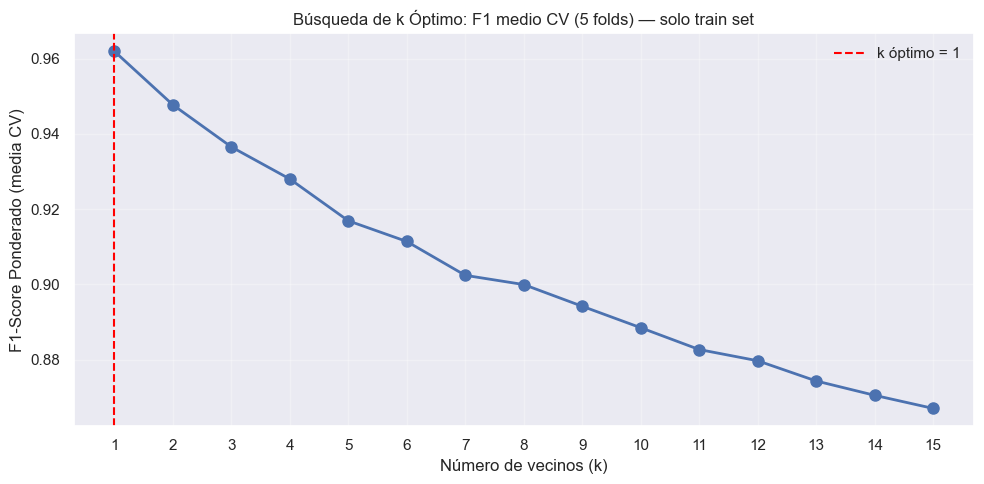


✓ k óptimo encontrado: 1
  F1-Score medio CV (train): 0.9620
  X_test no fue utilizado en este paso.


In [ ]:
# ===== PASO 4: BÚSQUEDA DE k ÓPTIMO CON CROSS-VALIDATION =====
# Se evalúa con StratifiedKFold sobre X_train_balanced — X_test NO se toca aquí.
# Cada fold actúa como validación interna; el test set queda reservado para evaluación final.

k_range = range(1, 16)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    fold_f1 = []
    for train_idx, val_idx in cv.split(X_train_balanced, y_train_balanced):
        X_fold_train, y_fold_train = X_train_balanced[train_idx], y_train_balanced[train_idx]
        X_fold_val,   y_fold_val   = X_train_balanced[val_idx],   y_train_balanced[val_idx]
        knn.fit(X_fold_train, y_fold_train)
        y_fold_pred = knn.predict(X_fold_val)
        fold_f1.append(f1_score(y_fold_val, y_fold_pred, average='weighted', zero_division=0))
    f1_scores.append(np.mean(fold_f1))

k_optimo_idx = np.argmax(f1_scores)
k_optimo = list(k_range)[k_optimo_idx]

plt.figure(figsize=(10, 5))
plt.plot(k_range, f1_scores, marker='o', linewidth=2, markersize=8)
plt.axvline(x=k_optimo, color='red', linestyle='--', label=f'k óptimo = {k_optimo}')
plt.title('Búsqueda de k Óptimo: F1 medio CV (5 folds) — solo train set')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('F1-Score Ponderado (media CV)')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ k óptimo encontrado: {k_optimo}")
print(f"  F1-Score medio CV (train): {max(f1_scores):.4f}")
print(f"  X_test no fue utilizado en este paso.")


In [ ]:
# ===== PASO 5: ENTRENAMIENTO FINAL CON k ÓPTIMO =====
# Entrenar SOLO con datos balanceados de TRAIN
knn_final = KNeighborsClassifier(n_neighbors=k_optimo, metric='cosine')
knn_final.fit(X_train_balanced, y_train_balanced)

print(f"✓ Modelo KNN entrenado con k={k_optimo}")
print(f"  Datos de entrenamiento: {X_train_balanced.shape[0]} muestras")

# Clasificar los tickets no clasificados
y_pred_no_clasificados = knn_final.predict(X_no_clasificados)
df_no_clasificados['Clasificación_predicha'] = y_pred_no_clasificados

print(f"\n✓ Clasificados {df_no_clasificados.shape[0]} tickets sin clasificar")
print('\nEjemplos de tickets no clasificados y su predicción:')
display(df_no_clasificados[['texto_unificado', 'Clasificación_predicha']].head(10))

✓ Modelo KNN entrenado con k=1
  Datos de entrenamiento: 11380 muestras

✓ Clasificados 4052 tickets sin clasificar

Ejemplos de tickets no clasificados y su predicción:


,texto_unificado,Clasificación_predicha
4,gentil ayuda siguiente caso clienta mayra jime...,chequeras
5,error cuenta historico plataforma permite desc...,sisrep
7,validacion pago credito estimados favor valida...,activo
9,coinciden valores pago credito ayuda favor cli...,activo
10,cliente maria sol salinas representante asocia...,cuenta
11,regresar cheque devuelto aplicativo bancs esti...,cheque
12,revision procesador contable bancs satelite mu...,bancslink
13,error dos inversiones devolucion total estimad...,cuenta
14,diferencia saldo contable disponible estimados...,cuenta
15,error cuenta salta inactiva portal movimientos...,bancslink


In [ ]:
# ===== PASO 6: EVALUACIÓN EN TEST SET (sin data leakage) =====
# Predecir en TEST SET (datos que el modelo NUNCA vio)
y_pred_test = knn_final.predict(X_test)

# Calcular métricas robustas
accuracy = accuracy_score(y_test, y_pred_test)
precision_weighted = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

print("\n" + "="*60)
print("EVALUACIÓN EN TEST SET (Datos nuevos)")
print("="*60)
print(f"Accuracy:              {accuracy:.4f}")
print(f"Precision (ponderado): {precision_weighted:.4f}")
print(f"Recall (ponderado):    {recall_weighted:.4f}")
print(f"F1-Score (ponderado):  {f1_weighted:.4f}")

print("="*60)
print("REPORTE DE CLASIFICACIÓN (Por clase):")
print(classification_report(y_test, y_pred_test, zero_division=0))



EVALUACIÓN EN TEST SET (Datos nuevos)
Accuracy:              0.7152
Precision (ponderado): 0.7063
Recall (ponderado):    0.7152
F1-Score (ponderado):  0.7069
REPORTE DE CLASIFICACIÓN (Por clase):
                        precision    recall  f1-score   support

                activo       0.82      0.91      0.86       109
             bancslink       0.73      0.75      0.74       142
               cartola       0.50      0.67      0.57         3
                cheque       0.53      0.57      0.55        30
             chequeras       0.75      0.80      0.77        30
               cliente       0.00      0.00      0.00         8
                  cnbs       0.25      1.00      0.40         1
          contabilidad       0.93      0.86      0.89        44
                cuenta       0.60      0.56      0.58        88
     estados de cuenta       0.43      0.50      0.46        12
    firmas autorizadas       0.33      0.12      0.18         8
        forma numerada       0.76 

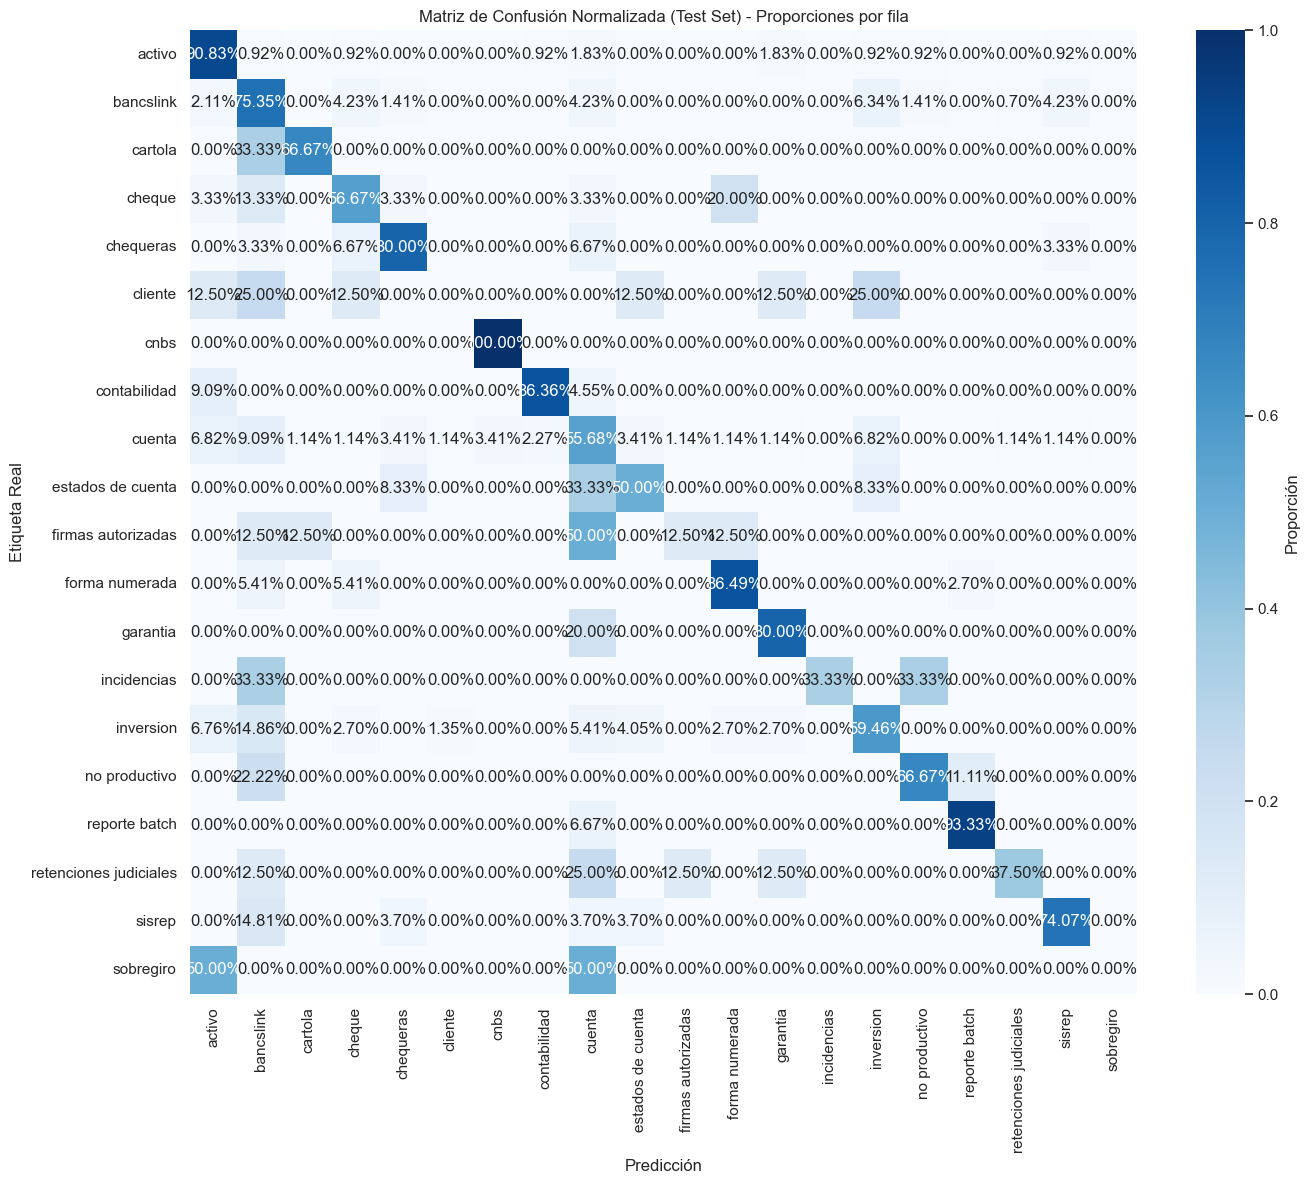

In [ ]:
# Visualizar matriz de confusión normalizada
labels = sorted(list(set(list(y_test) + list(y_pred_test))))
cm = confusion_matrix(y_test, y_pred_test)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Proporción'})
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión Normalizada (Test Set) - Proporciones por fila')
plt.tight_layout()
plt.show()


## Comparativa de Clasificadores

### Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_model.fit(X_train_balanced, y_train_balanced)

print("✓ Random Forest entrenado  (n_estimators=200)")


✓ Random Forest entrenado  (n_estimators=200)


### Logistic Regression

In [ ]:
lr_model = LogisticRegression(C=1.0, max_iter=3000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_balanced, y_train_balanced)

print("✓ Logistic Regression entrenada  (C=1.0)")


✓ Logistic Regression entrenada  (C=1.0)


In [ ]:

# ── Combinar los tres modelos y evaluar en test set ────────────────────────
modelos = {
    'KNN':                 knn_final,
    'Random Forest':       rf_model,
    'Logistic Regression': lr_model,
}

resultados = []
predicciones_modelos = {}
for nombre, modelo in modelos.items():
    y_pred_m = modelo.predict(X_test)
    predicciones_modelos[nombre] = y_pred_m
    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, y_pred_m),
        'F1-Score':  f1_score(y_test, y_pred_m, average='weighted', zero_division=0),
        'Precision': precision_score(y_test, y_pred_m, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, y_pred_m, average='weighted', zero_division=0)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')

print("=== Métricas comparativas (conjunto de prueba) ===\n")
print(df_resultados.round(4).to_string())

mejor = df_resultados['F1-Score'].idxmax()
print(f"\n► Mejor clasificador por F1-Score (weighted): {mejor}  "
      f"({df_resultados.loc[mejor, 'F1-Score']:.4f})")


=== Métricas comparativas (conjunto de prueba) ===

                     Accuracy  F1-Score  Precision  Recall
Modelo                                                    
KNN                    0.7152    0.7069     0.7063  0.7152
Random Forest          0.7939    0.7882     0.8003  0.7939
Logistic Regression    0.8076    0.8050     0.8182  0.8076

► Mejor clasificador por F1-Score (weighted): Logistic Regression  (0.8050)


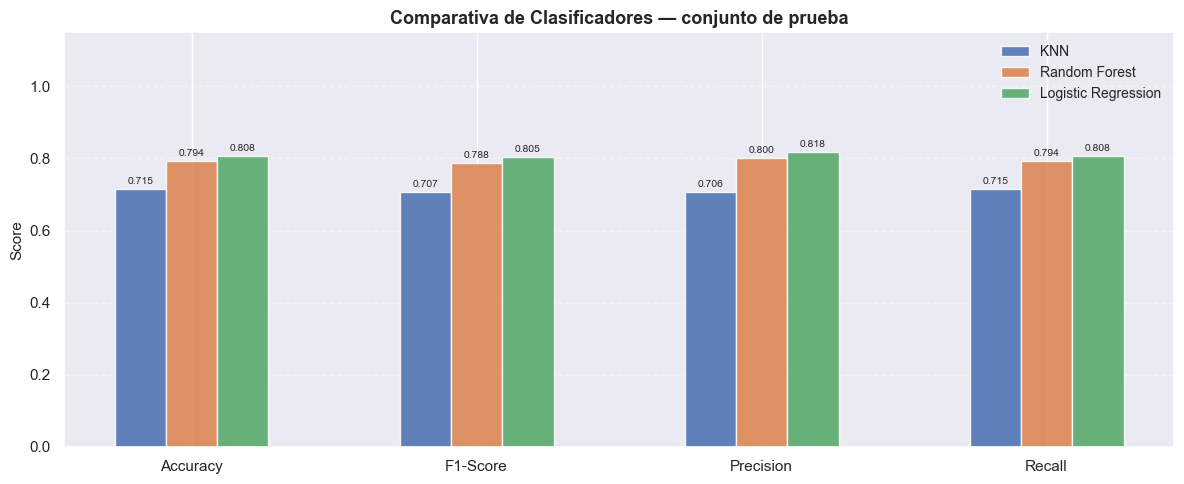

In [ ]:
metricas = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metricas))
n_modelos = len(df_resultados)
ancho = 0.18
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nombre, row) in enumerate(df_resultados.iterrows()):
    valores = [row[m] for m in metricas]
    barras = ax.bar(x + i * ancho, valores, ancho, label=nombre, color=colores[i], alpha=0.88)
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

offset_centro = (n_modelos - 1) * ancho / 2
ax.set_xticks(x + offset_centro)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparativa de Clasificadores — conjunto de prueba', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


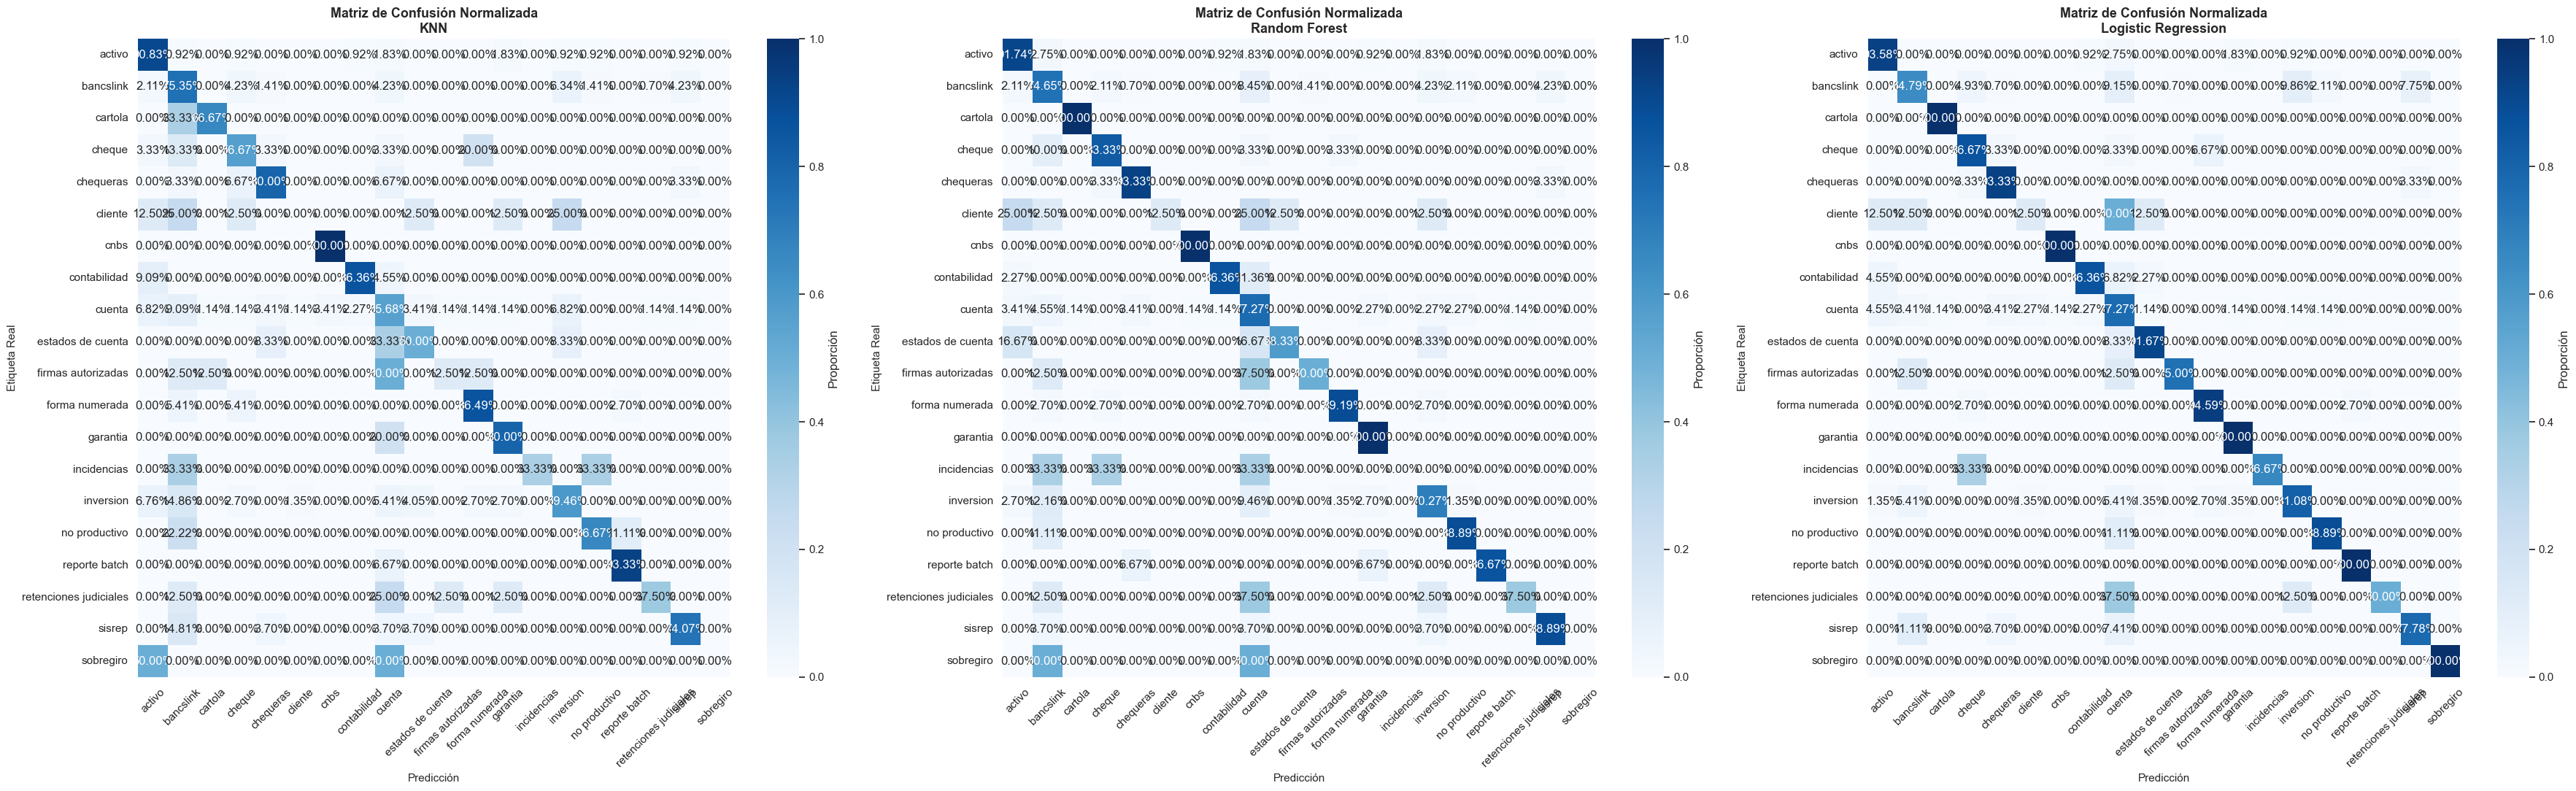

In [ ]:
labels = sorted(list(set(list(y_test))))
fig, axes = plt.subplots(1, 3, figsize=(36, 11))

for ax, (nombre, y_pred_m) in zip(axes, predicciones_modelos.items()):
    cm = confusion_matrix(y_test, y_pred_m, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2%', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        cbar_kws={'label': 'Proporción'}, ax=ax
    )
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Etiqueta Real', fontsize=11)
    ax.set_title(f'Matriz de Confusión Normalizada\n{nombre}', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


## Análisis de Errores

### Detalle de errores — Logistic Regression

In [ ]:

# ── Errores de Logistic Regression ───────────────────────────────────────────
y_pred_lr = predicciones_modelos['Logistic Regression']
mask_error_lr = y_test != y_pred_lr

errores_lr = df_test_base[mask_error_lr].copy()
errores_lr['y_predicha'] = y_pred_lr[mask_error_lr]

print(f"Logistic Regression  —  {mask_error_lr.sum()} errores de {len(y_test)} ({mask_error_lr.mean():.1%})")

# ── Top 15 pares más confundidos ──────────────────────────────────────────────
pares_lr = (errores_lr
            .groupby(['y_real', 'y_predicha'])
            .size()
            .reset_index(name='n')
            .sort_values('n', ascending=False)
            .head(15))

pares_lr['par'] = pares_lr['y_real'] + '  →  ' + pares_lr['y_predicha']

plt.figure(figsize=(10, 5))
plt.barh(pares_lr['par'][::-1], pares_lr['n'][::-1], color='#55A868', edgecolor='white', alpha=0.88)
plt.xlabel('Número de tickets confundidos')
plt.title('Top 15 pares más confundidos — Logistic Regression\n(real → predicha)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTabla detallada (top 15 pares):")
print(pares_lr[['y_real', 'y_predicha', 'n']].to_string(index=False))

# ── Tabla completa de tickets con error ───────────────────────────────────────
cols_display = [c for c in ['number', 'short_description', 'u_subcategory', 'y_real', 'y_predicha']
                if c in errores_lr.columns]
print(f"\nTickets mal clasificados ({len(errores_lr)} total):")
display(errores_lr[cols_display].reset_index(drop=True))


ValueError: Item wrong length 660 instead of 658.

## Generación de csv tickets ya clasificados tras algoritmo

In [ ]:

# ── Usar el mejor clasificador para predecir tickets no clasificados ──────────
mejor_modelo = modelos[mejor]
y_pred_final = mejor_modelo.predict(X_no_clasificados)

# ── Obtener confianza de la predicción ────────────────────────────────────────
# NOTA: LinearSVC no tiene predict_proba → se usa decision_function + softmax,
#       pero esos valores NO son probabilidades calibradas (son distancias al hiperplano).
#       Por eso se usa un umbral más bajo (0.10) cuando el modelo es LinearSVC.
if hasattr(mejor_modelo, 'predict_proba'):
    proba_matrix = mejor_modelo.predict_proba(X_no_clasificados)
    confianza = proba_matrix.max(axis=1)
    umbral_revision = 0.40
    tipo_confianza = 'probabilidad calibrada'
else:
    # Softmax sobre decision_function — no es probabilidad real, solo aproximación relativa
    scores = mejor_modelo.decision_function(X_no_clasificados)
    exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
    proba_matrix = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    confianza = proba_matrix.max(axis=1)
    umbral_revision = 0.10   # umbral ajustado para scores softmax de LinearSVC
    tipo_confianza = 'softmax(decision_function) — no calibrada'

# ── Construir DataFrame resultado ─────────────────────────────────────────────
cols_visibles = [c for c in ['number', 'short_description', 'description',
                              'u_subcategory', 'u_subcategory_2', 'texto_unificado',
                              'Clasificación']
                 if c in df_no_clasificados.columns]

df_resultado = df_no_clasificados[cols_visibles].copy()
df_resultado['Clasificación_predicha'] = y_pred_final
df_resultado['Confianza'] = np.round(confianza, 4)
df_resultado['Requiere_revision'] = confianza < umbral_revision
df_resultado['Modelo_usado'] = mejor

print(f"Modelo usado: {mejor}  |  Tipo de confianza: {tipo_confianza}")
print(f"Umbral de revisión aplicado: {umbral_revision}")
print(f"\nTotal de tickets clasificados: {len(df_resultado)}")
print(f"\nDistribución de predicciones:")
print(df_resultado['Clasificación_predicha'].value_counts().to_string())
print(f"\nTickets con baja confianza (< {umbral_revision}): {df_resultado['Requiere_revision'].sum()} "
      f"({df_resultado['Requiere_revision'].mean():.1%} del total)")


Modelo usado: Logistic Regression  |  Tipo de confianza: probabilidad calibrada
Umbral de revisión aplicado: 0.4

Total de tickets clasificados: 4052

Distribución de predicciones:
Clasificación_predicha
activo                    1169
bancslink                 1016
cuenta                     637
cheque                     278
contabilidad               179
chequeras                  137
forma numerada             130
inversion                  124
estados de cuenta           91
sisrep                      61
cliente                     52
no productivo               48
reporte batch               37
garantia                    33
firmas autorizadas          26
incidencias                 11
sobregiro                   11
cartola                      7
retenciones judiciales       5

Tickets con baja confianza (< 0.4): 1182 (29.2% del total)


In [ ]:
display(df_resultado)

,number,short_description,description,u_subcategory,u_subcategory_2,texto_unificado,Clasificación,Clasificación_predicha,Confianza,Requiere_revision,Modelo_usado
4,INC0756601,su gentil ayuda con el siguiente caso la clien...,su gentil ayuda con el siguiente caso la clien...,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,gentil ayuda siguiente caso clienta mayra jime...,sin_clasificar,chequeras,0.9431,False,Logistic Regression
5,INC0754937,Error Estado de Cuenta Histórico,Plataforma no permite descargar estado de cuen...,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,error cuenta historico plataforma permite desc...,sin_clasificar,cuenta,0.4792,False,Logistic Regression
7,INC0756747,VALIDACION DE PAGO DE CREDITO,"Estimados, por favor su validación si el pago ...",Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,validacion pago credito estimados favor valida...,sin_clasificar,activo,0.4630,False,Logistic Regression
9,INC0755311,No coinciden valores por pago de crédito,Su ayuda por favor cliente Pedro Barre con ci....,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,coinciden valores pago credito ayuda favor cli...,sin_clasificar,activo,0.8951,False,Logistic Regression
10,INC0746474,LA CLIENTE MARIA SOL SALINAS REPRESENTANTE DE ...,LA CLIENTE MARIA SOL SALINAS REPRESENTANTE DE ...,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,cliente maria sol salinas representante asocia...,sin_clasificar,cuenta,0.1478,True,Logistic Regression
...,...,...,...,...,...,...,...,...,...,...,...
7344,INC0261996,ERROR BANCS,ERROR al ingresar a bancs del usuario epsilva....,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,error bancs error ingresar bancs usuario epsil...,sin_clasificar,bancslink,0.3691,True,Logistic Regression
7346,INC0154817,error de cobro cliente 0605206614,"Estimados, favor su gentil ayuda cliente cance...",Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,error cobro cliente estimados favor gentil ayu...,sin_clasificar,activo,0.4028,False,Logistic Regression
7347,INC0139897,Seguir el flujo de la INC0020554 Su ayuda con ...,'--Marlon Seguir el flujo de la INC0020554 Su ...,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,seguir flujo ayuda correccion error saldos pre...,sin_clasificar,contabilidad,0.8609,False,Logistic Regression
7348,INC0085367,cancelación de cuanta y el documento para cie...,cancelación de cuanta y el documento para cie...,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,cancelacion cuanta documento cierre cuenta gen...,sin_clasificar,cuenta,0.4398,False,Logistic Regression


✓ CSV exportado: c:\Users\paomaribel\Documents\GitHub\Asignador\output\tickets_clasificados_Logistic_Regression_2026-06-02.csv
  Filas: 4052  |  Columnas: ['number', 'short_description', 'description', 'u_subcategory', 'u_subcategory_2', 'texto_unificado', 'Clasificación', 'Clasificación_predicha', 'Confianza', 'Requiere_revision', 'Modelo_usado']

  Alta confianza (≥ 0.4): 2870 tickets
  Requiere revisión  (< 0.4): 1182 tickets


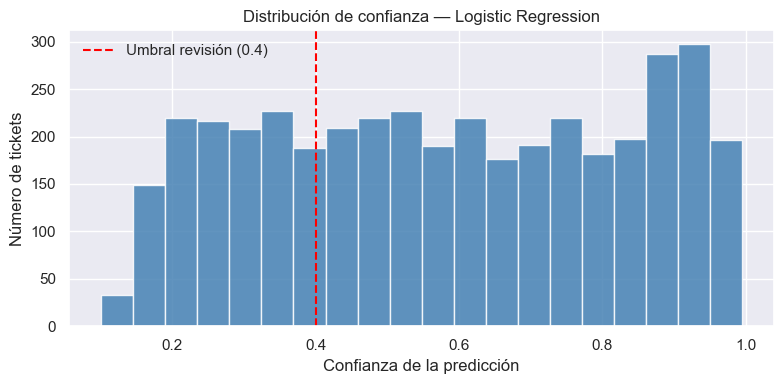

In [ ]:
from datetime import datetime

# Carpeta output/ al mismo nivel que Data/ (un nivel arriba de Analisis/)
fecha_hoy = datetime.now().strftime("%Y-%m-%d")
nombre_modelo_csv = mejor.replace(" ", "_")
nombre_archivo = f"tickets_clasificados_{nombre_modelo_csv}_{fecha_hoy}.csv"

carpeta_output = os.path.join(os.path.dirname(ruta_csv), '..', 'output')
os.makedirs(carpeta_output, exist_ok=True)

ruta_salida = os.path.normpath(os.path.join(carpeta_output, nombre_archivo))
df_resultado.to_csv(ruta_salida, index=False, encoding='utf-8-sig')

print(f"✓ CSV exportado: {ruta_salida}")
print(f"  Filas: {len(df_resultado)}  |  Columnas: {list(df_resultado.columns)}")
print(f"\n  Alta confianza (≥ {umbral_revision}): {(~df_resultado['Requiere_revision']).sum()} tickets")
print(f"  Requiere revisión  (< {umbral_revision}): {df_resultado['Requiere_revision'].sum()} tickets")

# ── Histograma de confianza ───────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(df_resultado['Confianza'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(umbral_revision, color='red', linestyle='--', linewidth=1.5,
            label=f'Umbral revisión ({umbral_revision})')
plt.xlabel('Confianza de la predicción')
plt.ylabel('Número de tickets')
plt.title(f'Distribución de confianza — {mejor}')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Persistencia del modelo y vectorizer ─────────────────────────────────────
# Se guardan juntos en la carpeta 'modelo/' para garantizar que la
# transformación TF-IDF sea idéntica al momento de inferencia futura.
nombre_modelo = mejor.replace(' ', '_')

carpeta_modelo = os.path.join(os.getcwd(), 'modelo')
os.makedirs(carpeta_modelo, exist_ok=True)

ruta_modelo     = os.path.join(carpeta_modelo, f'modelo_{nombre_modelo}.joblib')
ruta_vectorizer = os.path.join(carpeta_modelo, 'vectorizer_tfidf.joblib')

joblib.dump(mejor_modelo, ruta_modelo)
joblib.dump(vectorizer,   ruta_vectorizer)

print(f"✓ Modelo guardado:     {ruta_modelo}")
print(f"✓ Vectorizer guardado: {ruta_vectorizer}")
print()
print("Para cargar y usar en otro script:")
print(f"  modelo     = joblib.load('modelo/modelo_{nombre_modelo}.joblib')")
print(f"  vectorizer = joblib.load('modelo/vectorizer_tfidf.joblib')")
print(f"  X_nuevo    = vectorizer.transform(textos_nuevos)")
print(f"  prediccion = modelo.predict(X_nuevo)")


✓ Modelo guardado:     c:\Users\paomaribel\Documents\GitHub\Asignador\Analisis\modelo\modelo_Logistic_Regression.joblib
✓ Vectorizer guardado: c:\Users\paomaribel\Documents\GitHub\Asignador\Analisis\modelo\vectorizer_tfidf.joblib

Para cargar y usar en otro script:
  modelo     = joblib.load('modelo/modelo_Logistic_Regression.joblib')
  vectorizer = joblib.load('modelo/vectorizer_tfidf.joblib')
  X_nuevo    = vectorizer.transform(textos_nuevos)
  prediccion = modelo.predict(X_nuevo)
